# PyTorch Classification Tutorial: From Toy Data to CIFAR-10

This notebook is a step-by-step tutorial that starts with a simple binary classification problem and gradually moves to real image classification.

## Learning goals
- Understand a full PyTorch training workflow on a small synthetic dataset.
- Build intuition for model, loss function, optimizer, and evaluation.
- Apply the same pipeline to CIFAR-10 with an MLP baseline and then a CNN.

## Roadmap
1. Part 1: Binary classification with `make_circles`.
2. Part 2: CIFAR-10 classification with a strong MLP baseline.
3. Part 3: CIFAR-10 classification with a CNN (VGG-style + GAP).

In [1]:
# Part 1 setup: imports for synthetic binary classification
import pandas as pd
import numpy as np
from sklearn.datasets import make_circles

In [2]:
# Step 1.1: preparing a synthetic binary classification dataset
n_samples = 1000
X, y = make_circles(n_samples=n_samples, noise=0.05, random_state=42)
len(X), len(y)

(1000, 1000)

In [3]:
print(f"first five samples: \n{X[:5]}")
print(f"first five targets: {y[:5]}")

first five samples: 
[[ 0.74220688  0.24668576]
 [-0.7340323   0.16869164]
 [-0.82985872  0.22195899]
 [-0.42913559  0.67223019]
 [ 0.44560223 -0.89493556]]
first five targets: [1 1 1 1 0]


In [4]:
df = pd.DataFrame({
    "x1": X[:, 0],
    "x2": X[:, 1],
    "target": y
})

In [5]:
df.head()

,x1,x2,target
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0


## 1.2 Visualize the synthetic dataset

Before training, we inspect the feature space. `make_circles` creates two concentric classes, which is not linearly separable and is perfect for testing a small nonlinear network.

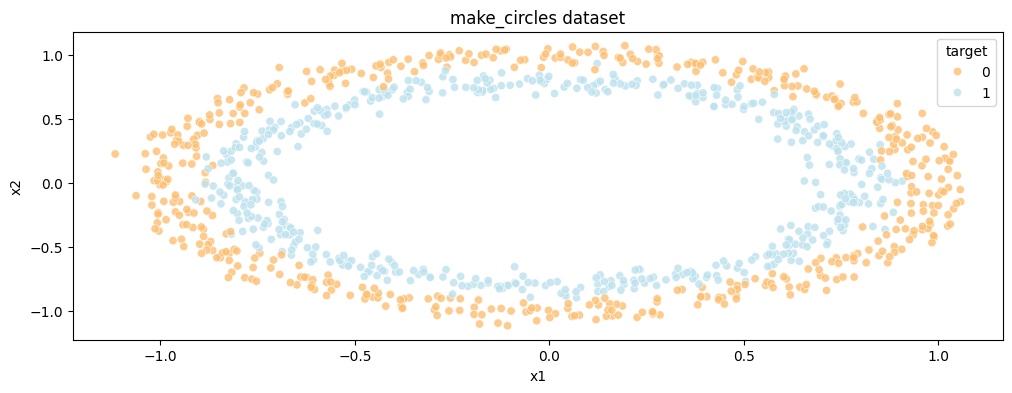

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
sns.scatterplot(data=df, x="x1", y="x2", hue="target", palette="RdYlBu", alpha=0.8)
plt.title("make_circles dataset")
plt.show()

In [7]:
import torch
print(torch.__version__)

KeyboardInterrupt: 

## 1.3 Move from NumPy to PyTorch tensors

PyTorch models operate on tensors. We convert `X` and `y` from NumPy arrays to `torch.float` tensors in the next step.

In [ ]:
# transforming our inputs into tensors
X  = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
X[:5], y[:5]

## 1.4 Train-test split

We split data before model training so we can evaluate generalization on unseen samples.

In [ ]:
torch.manual_seed(42)
# Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test)


In [ ]:
# Import Pytorch and nn
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device


## 1.5 Build a simple neural network for binary classification

This model takes 2D inputs (`x1`, `x2`) and outputs one logit per sample. We will later convert logits to class predictions using `sigmoid` + thresholding.

In [ ]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
model = CircleModelV0().to(device)
model

In [ ]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # weight = None, reduction = 'mean'

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## 1.6 Define loss, optimizer, and metric

- `BCEWithLogitsLoss` expects raw logits (no sigmoid inside the model output layer).
- We use SGD to update weights.
- A simple accuracy function compares predicted labels with ground truth.

In [ ]:
torch.manual_seed(42)
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train).squeeze()
    # Convert logits to binary class predictions for accuracy calculation.
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    if epoch % 10 == 0:
        print(f'Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%')

In [ ]:
device

### Checkpoint 1: What you completed

You built and trained a full binary classifier pipeline in PyTorch:
- generated synthetic data,
- converted arrays to tensors,
- trained with `BCEWithLogitsLoss`,
- evaluated on a held-out test set.

Next, we scale these ideas to a real image dataset (CIFAR-10).

# Part 2: CIFAR-10 Classification with an MLP Baseline

Now we move from toy data to real images. This section keeps the same training concepts, but applies them to a 10-class image classification task.

In [ ]:
# importing libraries
import torch
from torch import nn

import torchvision
import torchvision.transforms as T
from torch.utils.data import dataset, dataloader
from torchvision import datasets
from torchvision.transforms import ToTensor

import torchvision.models as models


## 2.1 Load the CIFAR-10 training dataset

### 2.1.1 Training split

In [ ]:
train_data = datasets.CIFAR10(root='data', train=True, transform=T.ToTensor(), download=True)

### 2.1.2 Test split

In [ ]:
test_data =  datasets.CIFAR10(root='data', train=False, transform=T.ToTensor(), download=True)

## 2.2 Check dataset size

In [ ]:
len(train_data), len(test_data)

## 2.3 Inspect one training example

In [ ]:
image, label = train_data[0]
image, label

In [ ]:
# classes names
train_data.classes

In [ ]:
train_data.class_to_idx

In [ ]:
image.shape, label

## 2.4 Visualize sample images

A quick visual check helps confirm labels and image formatting before training.

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(image.permute(1, 2, 0))
plt.title(train_data.classes[label])
plt.axis('off')
plt.show()

In [ ]:

# Convert to grayscale
grayscale_transform = T.Grayscale(num_output_channels=1)
grayscale_image = grayscale_transform(image)

plt.imshow(grayscale_image.permute(1, 2, 0), cmap='gray')
plt.title(train_data.classes[label])
plt.axis('off')
plt.show()

In [ ]:
class_images = {}
for image, label in train_data:
    if label not in class_images:
        class_images[label] = image
    if len(class_images) == len(train_data.classes):
        break

fig, axes = plt.subplots(2, 5, figsize=(14,5))
axes = axes.flatten()

for i, (label, image) in enumerate(class_images.items()):
    axes[i].imshow(image.permute(1,2,0))
    axes[i].set_title(train_data.classes[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 2.5 Build DataLoaders

DataLoaders handle batching and shuffling, which are essential for stable and efficient training.

In [ ]:
batch_size = 32
train_loader = dataloader.DataLoader(train_data, batch_size=batch_size, shuffle=True)

test_loader = dataloader.DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [ ]:
# let's check inside
train_image, train_label = next(iter(train_loader))
train_image.shape, train_label.shape

In [ ]:
# ploting sample from train_loader
fig, axes = plt.subplots(2, 5, figsize=(14,5))
axes = axes.flatten()
for i in range(10):
  axes[i].imshow(train_image[i].permute(1,2,0))
  axes[i].set_title(train_data.classes[train_label[i]])
  axes[i].axis("off")

plt.tight_layout()
plt.show()

## 2.6 Train a strong MLP baseline

This baseline flattens images and learns with fully connected layers. It is a useful reference point before introducing convolutional models.

In [ ]:
class CIFAR_MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(3072, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)

### 2.6.1 Set up model, loss, and optimizer

In [ ]:
# model intialization
device = "cuda" if torch.cuda.is_available() else "cpu"
model_cifr = CIFAR_MLP().to(device)

# criterion
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.AdamW(
    model_cifr.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

### 2.6.2 Training function

In [ ]:
def traning(model, loader):
  model.train()
  total_loss = 0
  for images, labels in loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    y_pred = model(images)
    loss = criterion(y_pred, labels) # similar to y_pred, y_test
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  return total_loss / len(loader)

### 2.6.3 Evaluation function

In [ ]:
def evaluation(model, loader):
  model.eval()
  correct = 0
  total = 0

  for images, labels in loader:
    images =  images.to(device)
    labels = labels.to(device)
    with torch.inference_mode():
      y_pred = model(images)
      preds = torch.argmax(y_pred, dim=1)
      correct += (preds == labels).sum().item()
      total += len(labels)
  return correct / total

### 2.6.4 Run training

In [ ]:
epochs = 100
train_losses = []
test_accuracies = []
for epoch in range(epochs):
  train_loss = traning(model_cifr, train_loader)
  test_acc = evaluation(model_cifr, test_loader)

  train_losses.append(train_loss)
  test_accuracies.append(test_acc)

  print(f"Epoch {epoch+1}")
  print("Loss:", train_loss)
  print("Test Accuracy:", test_acc)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(test_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Over Epochs")

plt.legend()
plt.show()

In [ ]:
# Saving model
from pathlib import Path

path = Path('model_CFIR')
path.mkdir(parents=True, exist_ok=True)

model_name = "model_cifr.pth"
save_name = path/model_name

torch.save(obj=model_cifr.state_dict(), f=save_name)

### 2.7 Load the saved MLP model and test one sample

In [ ]:
model_loaded = CIFAR_MLP()
model_loaded.load_state_dict(torch.load(save_name))


In [ ]:
image, label = test_data[1]
image = image.to(device) # Move image to the correct device
model_loaded.to(device) # Ensure model is also on the device
model_loaded.eval()
with torch.inference_mode():
  y_pred_logits = model_loaded(image.unsqueeze(0)) # Add a batch dimension if needed

y_pred = torch.argmax(y_pred_logits, dim=1)

print(f"Predicted: {train_data.classes[y_pred.item()]}")
print(f"Ground Truth: {train_data.classes[label]}")

### Checkpoint 2: Baseline complete

You trained an end-to-end CIFAR-10 MLP baseline and reviewed its learning curves. Next, we switch to a CNN architecture that is better suited to image data.

# Part 3: CIFAR-10 with a CNN (VGG-style + Global Average Pooling)

Convolutional networks usually outperform MLPs on images because they preserve spatial structure.

## 3.1 Imports and dataset setup

In [ ]:
import torch
from torch import nn
from torchvision.datasets import CIFAR10
from torch.utils.data import dataset, dataloader

from torchvision.transforms import transforms

### 3.1.1 Define data augmentation and normalization

In [ ]:
# 1. Data Transforms & Loaders
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

### 3.1.2 Build datasets and DataLoaders

In [ ]:
train_data = CIFAR10(root='data', download=True, train=True, transform=transform_train)
test_data = CIFAR10(root='data', download=True, train=False, transform=transform_test)

train_loader = dataloader.DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = dataloader.DataLoader(test_data, batch_size=32, shuffle=False)

### 3.1.3 Visual sanity check of a training batch

In [ ]:
train_image, train_label = next(iter(train_loader))
train_image.shape, train_label.shape

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ploting sample from train_loader
fig, axes = plt.subplots(2, 5, figsize=(14,5))
axes = axes.flatten()
for i in range(10):
  # Inverse normalize the image before displaying
  # The normalization values are from transform_train in cell 6.2
  mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
  std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
  display_image = train_image[i] * std + mean
  # Clip the values to [0, 1] in case of any outliers after inverse normalization
  display_image = torch.clamp(display_image, 0, 1)

  axes[i].imshow(display_image.permute(1,2,0))
  axes[i].set_title(train_data.classes[train_label[i]])
  axes[i].axis("off")

plt.tight_layout()
plt.show()

## 3.2 Build the CNN model (VGG-style)

In [ ]:
import torch
import torch.nn as nn

class VGG16_GAP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.convolutional_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU()
            # The 5th MaxPool is removed, handled by GAP instead
        )

        # Global Average Pooling Trick
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Drastically shrunken classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.convolutional_layers(x)
        x = self.global_avg_pool(x)
        x = self.classifier(x)
        return x

### 3.2.1 Device configuration

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGG16_GAP().to(device)

### 3.2.2 Loss, optimizer, and learning-rate scheduler

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

## 3.3 Training function

In [ ]:
# 4. Training and Eval Functions
def training(model, loader, optimizer, criterion, device):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return train_loss / len(loader), 100. * correct / total

## 3.4 Evaluation function

In [ ]:
def evaluation(model, loader, criterion, device):
    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            test_loss += criterion(outputs, targets).item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return test_loss / len(loader), 100. * correct / total

## 3.5 Final CNN training loop

In [ ]:
# 5. Main Loop
epochs = 100
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(epochs):
    tr_loss, tr_acc = training(model, train_loader, optimizer, criterion, device)
    scheduler.step() # Step the scheduler after each epoch
    te_loss, te_acc = evaluation(model, test_loader, criterion, device)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {tr_acc:.2f}% | Test Acc: {te_acc:.2f}%")

## 3.6 Visualize loss and accuracy curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(train_losses, color='red', label='Train Loss')
ax1.plot(test_losses, color='orange', label='Test Loss')
ax1.set_title("Loss")
ax1.legend()

ax2.plot(train_accs, color='blue', label='Train Acc')
ax2.plot(test_accs, color='cyan', label='Test Acc')
ax2.set_title("Accuracy")
ax2.legend()
plt.show()


## 3.7 Save the trained CNN model

In [ ]:
torch.save(model.state_dict(), 'cifar10_vgg16_gap.pth')
print("Model saved!")

# Final Summary

You completed a full progression:
1. Binary classification on synthetic circles to learn the PyTorch training loop.
2. CIFAR-10 baseline with an MLP.
3. CIFAR-10 improvement with a CNN that better uses image structure.

## Suggested next experiments
- Try different optimizers and learning rates.
- Add early stopping and model checkpointing.
- Compare this custom CNN with transfer learning from pretrained models.